<a href="https://colab.research.google.com/github/Leitekaique/data-analytics-portfolio/blob/project-1-olist/Olist_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Estratégica do E-commerce Olist

### Análise de negócio - Comercial, Logistica e Experiência do Consumidor

**Março/2026**  
**Kaique Leite**  
**Fonte:** Olist (Kaggle)

### Resumo Executivo

- **Onde crescer:** Beleza, relógios e cama/mesa/banho concentram 40% da receita — foque nelas.

- **Onde a logística falha:** Atrasos derrubam a nota de 4,29 para 2,57. Norte tem prazo 20 dias maior que SP.

- **Oportunidade de pricing:** Produtos de ferramentas/jardim têm preço 50% abaixo da média — chance de reajuste

## 1 - Contexto do Problema
 Este projeto analisa dados públicos do e-commerce brasileiro (Olist) com o objetivo de responder perguntas estratégicas para áreas de Comercial, Logistica e Experiência do Consumidor.

As principais áreas de investigação são:
- Performance financeira por categoria
- Oportunidades de pricing e sortimento
- Eficiência logística e impacto na satisfação

Ferramentas utilizadas: SQL (análise de dados), Python (Pandas/Matplotlib para visualizações) e estatística descritiva.

Dataset utilizado https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

## 1 - Setup do ambiente

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.1 - Carregando os dados

In [ ]:
from numpy import geomspace
from numpy._core.fromnumeric import prod
import pandas as pd

orders = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_orders_dataset.csv")
order_review = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_order_payments_dataset.csv")
customers = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_customers_dataset.csv")
products = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_products_dataset.csv")
sellers = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_sellers_dataset.csv")
geolocation = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/olist_geolocation_dataset.csv")
product_name = pd.read_csv("/content/drive/MyDrive/Data/Cases/Projeto_Olist_Customer_Dataset/data/product_category_name_translation.csv")

### 1.2 - Imports

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sqlite3
conn = sqlite3.connect("case.db")

### 1.3 - Criação das tabelas

In [ ]:
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_review.to_sql("order_review", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
order_payments.to_sql("order_payments", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
sellers.to_sql("sellers", conn, index=False, if_exists="replace")
geolocation.to_sql("geolocation", conn, index=False, if_exists="replace")
product_name.to_sql("product_name", conn, index=False, if_exists="replace")

71

### 1.4 - Função auxiliar para executar o SQL

In [ ]:
def run_query(query):
  return pd.read_sql_query(query, conn)

## 2 - Análise exploratória dos dados

### 2.1 - Dados gerais

In [ ]:
df_ticket_medio_geral = run_query("""
with tm as (
  select
    sum(oi.price) as receita_total,
    AVG(oi.price ) as pm,
    count(oi.order_id ) as qtd_itens,
    count(distinct(o.order_id)) as qtd_pedidos,
    avg(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as tempo_entrega_medio
  from order_items oi
  left join orders o on oi.order_id = o.order_id
  where o.order_status in ("delivered","approved","shipped")
)
select
  round(receita_total,0) as receita_total,
  round((receita_total/qtd_pedidos),2) as ticket_medio_geral,
  round(pm,2) as preco_medio_geral,
  qtd_itens,
  qtd_pedidos,
  round(tempo_entrega_medio,0) as tempo_entrega_medio
from tm
""")

display(df_ticket_medio_geral)

,receita_total,ticket_medio_geral,preco_medio_geral,qtd_itens,qtd_pedidos,tempo_entrega_medio
0,13372435.0,137.03,120.06,111385,97586,12.0


### 2.2 - Preço médio por categoria

In [ ]:
df_media_preco_categoria = run_query("""
SELECT p.product_category_name,
  AVG(oi.price) as preco_medio
FROM orders o
LEFT JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN products p ON oi.product_id = p.product_id
WHERE o.order_status IN ("delivered","approved","shipped")
GROUP BY p.product_category_name
ORDER BY preco_medio DESC
""")

display(df_media_preco_categoria)

,product_category_name,preco_medio
0,pcs,1095.609604
1,portateis_casa_forno_e_cafe,631.447333
2,eletrodomesticos_2,470.849957
3,agro_industria_e_comercio,343.653886
4,instrumentos_musicais,282.936840
...,...,...
69,alimentos_bebidas,55.530185
70,cds_dvds_musicais,52.142857
71,fraldas_higiene,40.494474
72,flores,33.637576


### 2.3 - Distribuição das notas de review

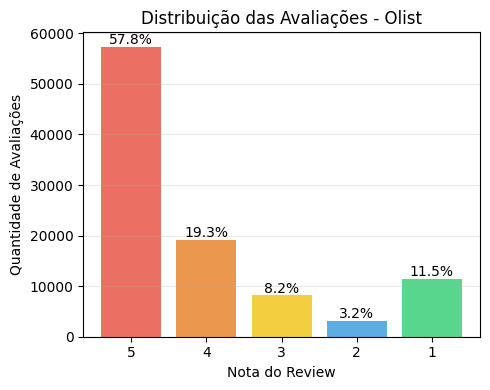

In [ ]:
df_notas = run_query("""
select t.review_score ,
  count(order_id) as qtd
from order_review t
group by t.review_score
order by t.review_score desc
""")

plt.figure(figsize=(5, 4))
cores_notas = ['#E74C3C', '#E67E22', '#F1C40F', '#3498DB', '#2ECC71']
bars = plt.bar(df_notas['review_score'].astype(str), df_notas['qtd'],
               color=cores_notas, alpha=0.8)

total = df_notas['qtd'].sum()
for bar, qtd in zip(bars, df_notas['qtd']):
    percentual = 100 * qtd / total
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{percentual:.1f}%', ha='center', fontsize=10)

plt.xlabel('Nota do Review')
plt.ylabel('Quantidade de Avaliações')
plt.title('Distribuição das Avaliações - Olist')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Ticket médio geral: 120 reais
- Total de pedidos: 97586 (entregues, aprovados e despachados)
- Total de itens vendidos: 111385
- Top3 categorias com maiores ticket médio: pcs, portateis_casa_forno_e_cafe e eletrodometicos_2
- 57,8% dos pedidos têm nota 5, mas 14,7% têm notas 2 ou 1

## 3 - Análise Comercial: Oportunidades de crescimento de receita

### 3.1 - Quem são os campeões de receita? (Top 10 categorias)

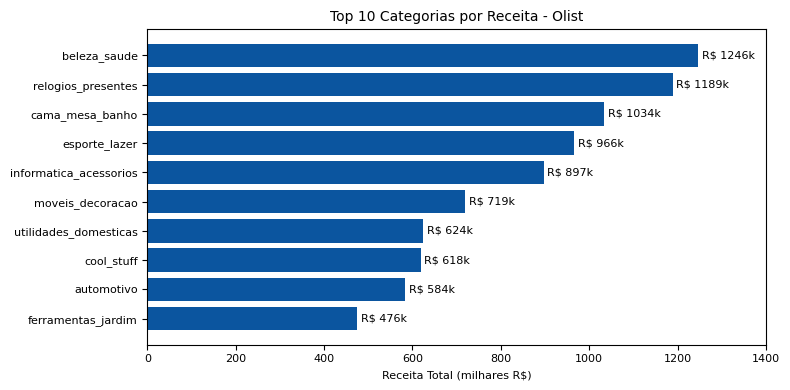

In [ ]:
df_receita_categoria = run_query("""
  select p.product_category_name,
	  (avg(oi.price)*(count(oi.order_id )*1.0)) as receita_total,
	  AVG(oi.price ) as pm,
	  count(oi.order_id ) as qtd
	from orders o
	left join order_items oi on o.order_id = oi.order_id
	left join products p on oi.product_id = p.product_id
	where o.order_status in ("delivered","approved","shipped")
	GROUP BY 1
  order by receita_total desc;
""")

top10_receita = df_receita_categoria.head(10).copy()

plt.figure(figsize=(8, 4))
sns.set_palette("Blues_r")

bars = plt.barh(top10_receita['product_category_name'], top10_receita['receita_total']/1000)


for i, (bar, valor) in enumerate(zip(bars, top10_receita['receita_total']/1000)):
    plt.text(valor + 8, bar.get_y() + bar.get_height()/2,
             f'R$ {valor:.0f}k', va='center', fontsize=8)

plt.xlabel('Receita Total (milhares R$)', fontsize=8)
plt.title('Top 10 Categorias por Receita - Olist', fontsize=10)
plt.tick_params(axis='y', labelsize=8)
plt.tick_params(axis='x', labelsize=8)
plt.xlim(right=1400)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Análise de negócio:

- Beleza e saúde lidera com R$ 1,24M em receita, seguida por relógios e presentes.
- Juntas, as top 5 categorias concentram 40% da receita total.
- Isso significa que ações de marketing e sortimento devem priorizar esses segmentos.

Recomendação:
- Alocar 60% do orçamento de marketing nas top 3 categorias
- Criar bundles (combos) entre produtos dessas categorias para aumentar ticket médio

### 3.2 - Oportunidades de pricing: produtos populares com preço abaixo da média


In [ ]:
df_alto_volume = run_query("""
with pm as(
  select
    AVG(oi.price ) as pm_geral,
    count(oi.order_id ) as qtd_geral
  from order_items oi
  where oi.shipping_limit_date is not null
),
top10 as (
  SELECT oi.product_id ,
    p.product_category_name ,
    AVG(oi.price ) pm_produto,
    COUNT (oi.order_id ) as qtd_produto
  from order_items oi
  left join products p on oi.product_id = p.product_id
  group by oi.product_id
),
pm_categoria as (
  select p.product_category_name,
	  AVG(oi.price ) as pm_categoria
	from order_items oi
	left join orders o on o.order_id = oi.order_id
	left join products p on oi.product_id = p.product_id
	where o.order_status in ("delivered","approved","shipped")
  group by product_category_name
)
SELECT t.product_id ,
  t.product_category_name ,
  t.pm_produto ,
  pc.pm_categoria ,
  t.qtd_produto
FROM top10 t
join pm
left join pm_categoria pc on t.product_category_name = pc.product_category_name
where t.pm_produto < pm.pm_geral
group by t.product_id
order by t.qtd_produto  desc
limit 10;
""")
display(df_alto_volume)

,product_id,product_category_name,pm_produto,pm_categoria,qtd_produto
0,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,71.364137,87.214737,527
1,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,88.167131,93.403912,488
2,422879e10f46682990de24d770e7f83d,ferramentas_jardim,54.911612,110.408702,484
3,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,54.695383,110.408702,392
4,368c6c730842d78016ad823897a372db,ferramentas_jardim,54.270103,110.408702,388
5,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,54.657373,110.408702,373
6,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,116.666935,200.513503,323
7,154e7e31ebfa092203795c972e5804a6,beleza_saude,22.509573,130.049703,281
8,2b4609f8948be18874494203496bc318,beleza_saude,87.373923,130.049703,260
9,7c1bd920dbdf22470b68bde975dd3ccf,beleza_saude,60.028961,130.049703,231


Análise de negócio:

- Identificamos produtos com alto volume de vendas e preço significativamente abaixo da média da categoria. Exemplo: produtos de ferramentas e jardim com preço ~54 reais vs média da categoria de 110 reais.
- Isso pode indicar oportunidade de aumento de preço sem perda significativa de vendas, desde que a elasticidade seja baixa.

Recomendação:

- Testar aumento gradual de 5-10% nos produtos identificados, monitorando volume
- Para produtos de beleza com preço muito baixo (ex: 22 reais vs média 130 reais), avaliar se são produtos de entrada (isca) ou se há margem para reajuste

### 3.3 - Sazonalidade de vendas

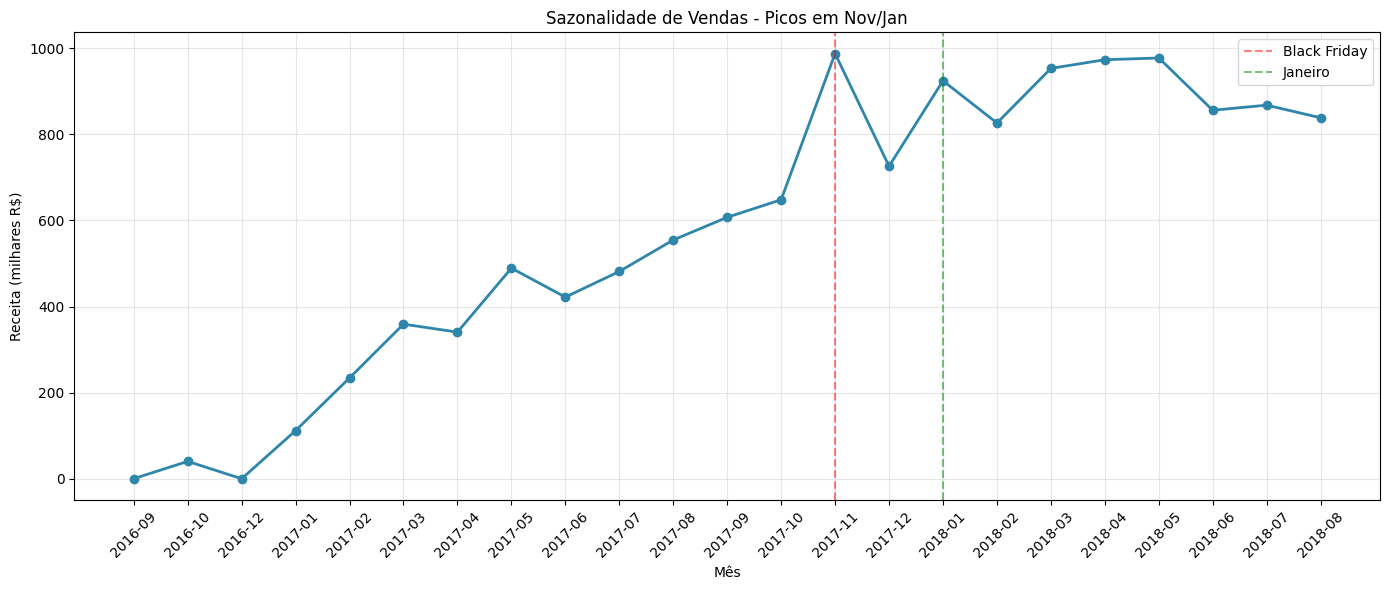

In [ ]:
df_sazonalidade = run_query("""
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS mes,
        COUNT(DISTINCT o.order_id) AS total_pedidos,
        SUM(oi.price) AS receita_mensal
    FROM orders o
    LEFT JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1
""")

plt.figure(figsize=(14, 6))
plt.plot(df_sazonalidade['mes'], df_sazonalidade['receita_mensal']/1000,
         marker='o', linewidth=2, color='#2E86AB')
plt.axvline(x='2017-11', color='red', linestyle='--', alpha=0.5, label='Black Friday')
plt.axvline(x='2018-01', color='green', linestyle='--', alpha=0.5, label='Janeiro')
plt.xlabel('Mês')
plt.ylabel('Receita (milhares R$)')
plt.title('Sazonalidade de Vendas - Picos em Nov/Jan')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Análise de negócio:
Observamos um pico expressivo em novembro (Black Friday) e também em janeiro. Isso indica forte sazonalidade e necessidade de planejamento antecipado de estoque e campanhas."

Recomendações:

- Iniciar campanhas de aquecimento para Black Friday em setembro
- Garantir estoque 2x maior para as top categorias em outubro
- Preparar equipe de logística para volume 40% maior em novembro

## 4. Análise de Logística: Como a melhora logística pode aumentar as vendas

### 4.1 - Mapa de calor logístico: tempo de entrega por estado

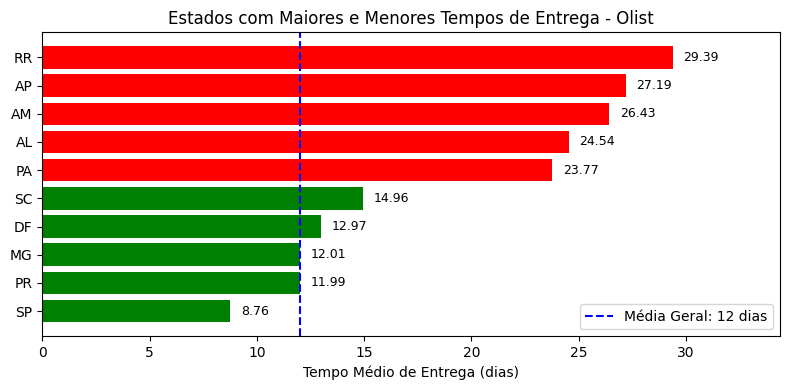

In [ ]:
df_estados_tempo = run_query("""
with frete as (
  select o.order_id ,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    ((julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp))) as tempo_entrega_dias,
    ((julianday(o.order_estimated_delivery_date) - julianday(o.order_purchase_timestamp))) as prazo_de_entrega
  from orders o
  where o.order_delivered_customer_date <> "" and o.order_purchase_timestamp <> ""
)
SELECT c.customer_state ,
  avg(f.tempo_entrega_dias) as medio_tempo_entrega,
  avg(f.prazo_de_entrega) as medio_prazo_entrega
from frete f
left join orders o1 on f.order_id = o1.order_id
left join customers c on o1.customer_id = c.customer_id
where f.tempo_entrega_dias is not null
group by 1
order by medio_tempo_entrega desc;
""")

df_plot_sorted = df_estados_tempo.sort_values('medio_tempo_entrega', ascending=False)
top_5_states = df_plot_sorted.head(5)
bottom_5_states = df_plot_sorted.tail(5)

df_plot_filtered = pd.concat([top_5_states, bottom_5_states])
df_plot_filtered = df_plot_filtered.sort_values('medio_tempo_entrega', ascending=False)

df_plot_filtered['cor'] = ['red'] * 5 + ['green'] * 5 # Red for top 5, Green for bottom 5

plt.figure(figsize=(8, 4))
bars = plt.barh(df_plot_filtered['customer_state'],
                df_plot_filtered['medio_tempo_entrega'],
                color=df_plot_filtered['cor'])

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{df_plot_filtered.iloc[i]['medio_tempo_entrega']:.2f}', va='center', ha='left', fontsize=9)

plt.xlabel('Tempo Médio de Entrega (dias)')
plt.title('Estados com Maiores e Menores Tempos de Entrega - Olist')
plt.xlim(right=df_plot_filtered['medio_tempo_entrega'].max() + 5)
plt.gca().invert_yaxis()

media_geral_tempo_entrega = df_ticket_medio_geral['tempo_entrega_medio'].iloc[0]
plt.axvline(x=media_geral_tempo_entrega, color='blue', linestyle='--', label=f'Média Geral: {media_geral_tempo_entrega:.0f} dias')
plt.legend()

plt.tight_layout()
plt.show()

### Análise de negócio:

Há uma clara desigualdade entre os prazos logísticos no Brasil. Enquanto SP entrega em média em 8,7 dias, RR leva 29,3 dias — uma diferença de 20 dias. Isso impacta diretamente a satisfação do cliente e a taxa de recompra nessas regiões.

Recomendação:

- Médio prazo: Negociar com transportadoras locais ou criar centro de distribuição regional em Manaus ou Fortaleza
- Longo prazo: Avaliar viabilidade de hubs regionais

### 4.2 - Ticket médio por Estado

/tmp/ipykernel_457/1830622824.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ticket_medio', y='customer_state', data=df_tm_estado, palette='viridis')


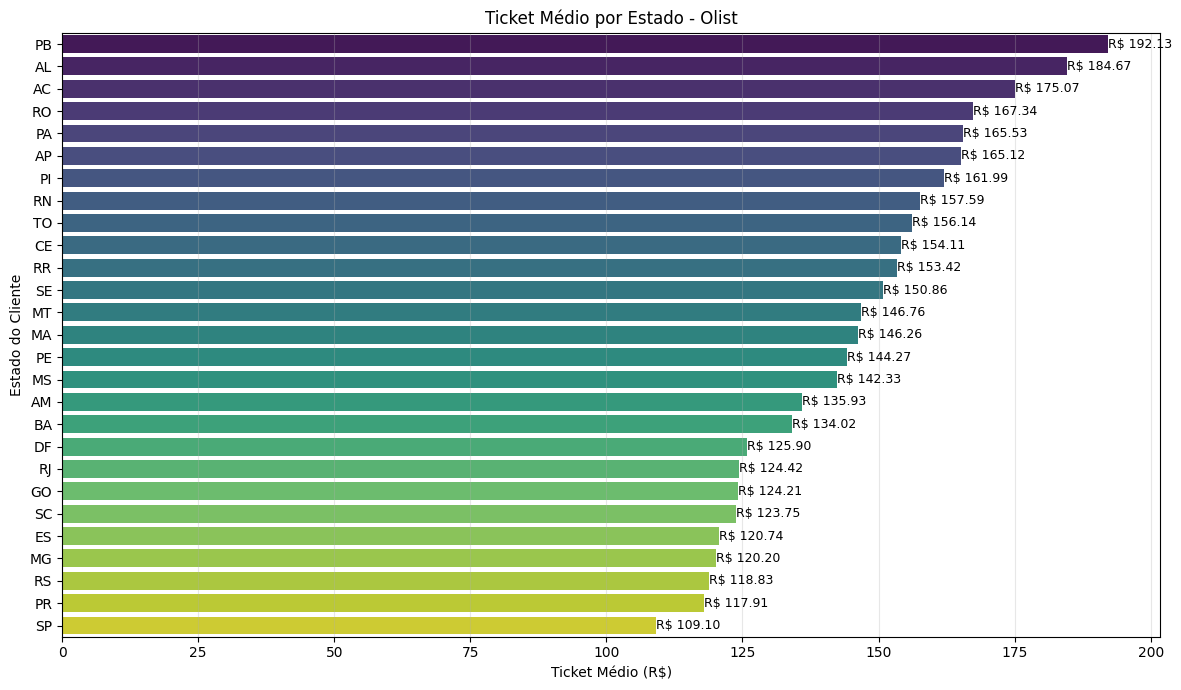

/tmp/ipykernel_457/1830622824.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_items_pedidos', y='customer_state', data=df_tm_estado, palette='viridis')


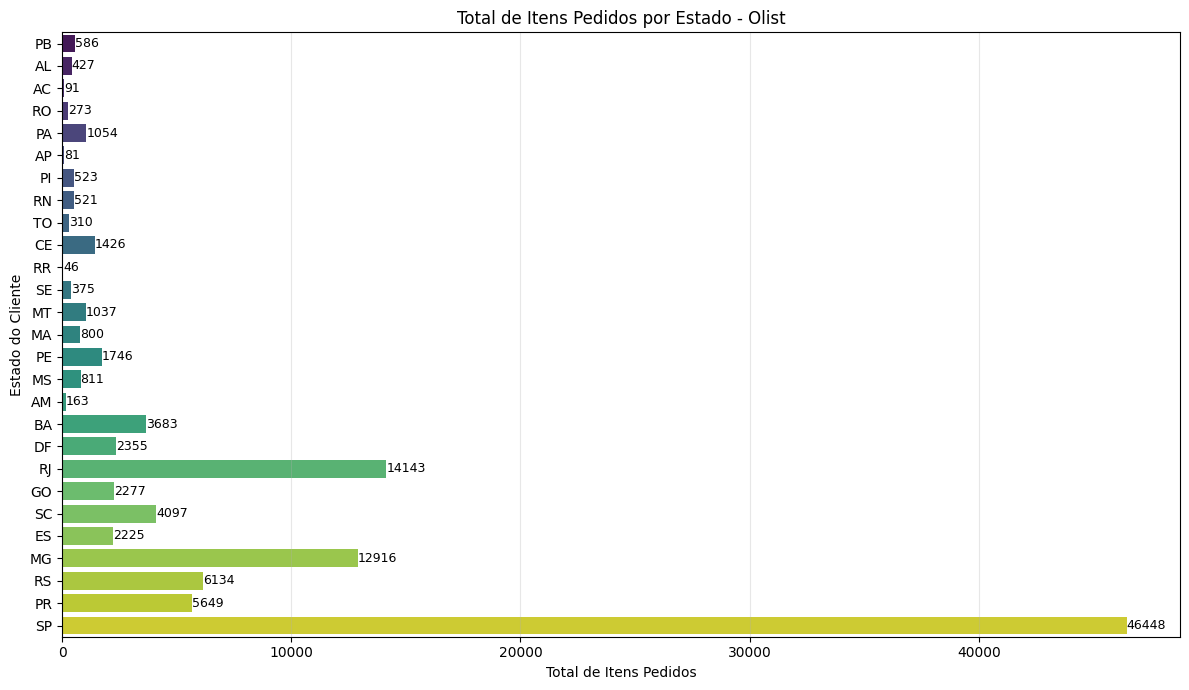

In [ ]:
df_tm_estado = run_query("""
    SELECT
        c.customer_state,
        COUNT(oi.order_id) AS total_items_pedidos,
        SUM(oi.price) AS receita_total,
        AVG(oi.price) AS ticket_medio
    FROM orders o
    LEFT JOIN order_items oi ON o.order_id = oi.order_id
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_state
    ORDER BY ticket_medio DESC
""")

plt.figure(figsize=(12, 7))
sns.barplot(x='ticket_medio', y='customer_state', data=df_tm_estado, palette='viridis')

# Adiciona os valores do ticket médio nas barras
for index, row in df_tm_estado.iterrows():
    plt.text(row.ticket_medio, index, f'R$ {row.ticket_medio:.2f}', color='black', ha="left", va="center", fontsize=9)

plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Estado do Cliente')
plt.title('Ticket Médio por Estado - Olist')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='total_items_pedidos', y='customer_state', data=df_tm_estado, palette='viridis')

# Adiciona os valores nas barras
for index, row in df_tm_estado.iterrows():
    plt.text(row.total_items_pedidos, index, f'{int(row.total_items_pedidos)}', color='black', ha="left", va="center", fontsize=9)

plt.xlabel('Total de Itens Pedidos')
plt.ylabel('Estado do Cliente')
plt.title('Total de Itens Pedidos por Estado - Olist')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Análise de negócio:

Estados como PB, AL e AC têm ticket médio acima de 172 reais, enquanto SP, PR e RS têm ticket abaixo de 109 reais. Isso sugere diferentes perfis de consumo e poder aquisitivo.
Analisando o ticket médio, volume de itens pedidos e tempo de entrega por estado vemos que esses três parâmetros se conectam:
- Maior tempo de entrega, menor voume de vendas, maior ticket médio (compras planejadas itens com valores maiores).
- Menor tempo de entrega, maior volume de vendas, menor ticket médio (compras mais constantes itens variados)

Recomendação:
- Para estados com alto ticket: oferecer parcelamento maior e produtos premium
-  Para estados com baixo ticket: testar frete grátis a partir de valor mais baixo (ex: R$99)

## 5. Análise de Customer Experience: Como o tempo de entrega impacta a satisfação?

### 5.1 - Tempo de entrega vs satisfação do cliente

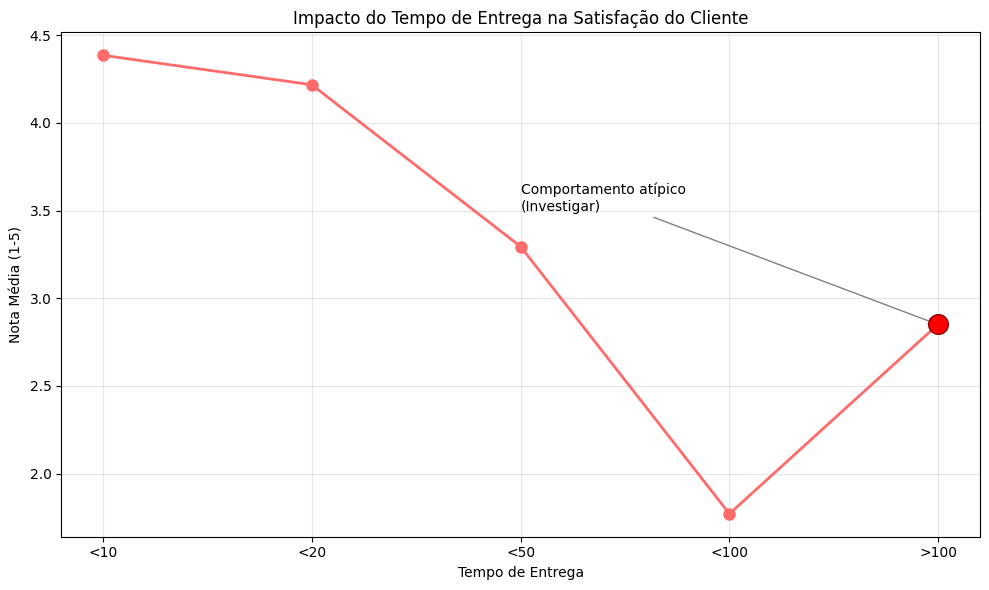

In [ ]:
df_tempo_score = run_query("""
with frete as (
  select o.order_id ,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    ((julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp))) as tempo_entrega_dias,
    t.review_score as score
  from orders o
  left join order_review t on o.order_id = t.order_id
  where o.order_delivered_customer_date <> "" and o.order_purchase_timestamp <> "" and t.review_score is not null
  group by o.order_id
)
select
CASE
  when f.tempo_entrega_dias <= 10 then "1"
  when f.tempo_entrega_dias > 10 and f.tempo_entrega_dias <= 20 then "2"
  when f.tempo_entrega_dias > 20 and f.tempo_entrega_dias <= 50 then "3"
  when f.tempo_entrega_dias > 50 and f.tempo_entrega_dias <= 100 then "4"
  else "5"
end as ranking,
CASE
  when f.tempo_entrega_dias <= 10 then "<10"
  when f.tempo_entrega_dias > 10 and f.tempo_entrega_dias <= 20 then "<20"
  when f.tempo_entrega_dias > 20 and f.tempo_entrega_dias <= 50 then "<50"
  when f.tempo_entrega_dias > 50 and f.tempo_entrega_dias <= 100 then "<100"
  else ">100"
  end as tempo_entrega,
  avg(f.score) as score_medio
from frete f
group by 1
order by ranking
""")

ordem_faixas = ['<10', '<20', '<50', '<100', '>100']
df_tempo_score['ordem'] = df_tempo_score['tempo_entrega'].map(
    {v: i for i, v in enumerate(ordem_faixas)})
df_plot = df_tempo_score.sort_values('ordem')

plt.figure(figsize=(10, 6))
plt.plot(df_plot['tempo_entrega'], df_plot['score_medio'],
         marker='o', linewidth=2, markersize=8, color='#FF6B6B')

# Destaque para o ponto atípico (>100)
plt.scatter(['>100'],
            [df_plot[df_plot['tempo_entrega']=='>100']['score_medio'].values[0]],
            color='red', s=200, zorder=5, edgecolors='darkred')

plt.xlabel('Tempo de Entrega')
plt.ylabel('Nota Média (1-5)')
plt.title('Impacto do Tempo de Entrega na Satisfação do Cliente')
plt.grid(True, alpha=0.3)

plt.annotate('Comportamento atípico\n(Investigar)',
             xy=('>100', 2.85), xytext=('<50', 3.5),
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

### 5.2 - Deep dive nas entregas acima de 100 dias

In [ ]:
df_entrega_cem_dias = run_query("""
with frete as (
	select o.order_id ,
    t.review_score as score,
    o.order_purchase_timestamp as data_compra,
    o.order_delivered_customer_date as data_entrega,
    o.order_estimated_delivery_date as data_estimada,
    ((julianday(o.order_estimated_delivery_date ) - julianday(o.order_purchase_timestamp))) as tempo_estimado,
    ((julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp))) as tempo_entrega_dias,
    avg(oi.freight_value) as media_frete
  from orders o
  left join order_review t	on o.order_id = t.order_id
  left join order_items oi on o.order_id = oi.order_id
	where o.order_delivered_customer_date <> "" and o.order_purchase_timestamp <> "" and t.review_score is not null
	group by o.order_id
	)
SELECT
  f.score,
	f.tempo_entrega_dias ,
	f.tempo_estimado ,
  round(f.tempo_entrega_dias - f.tempo_estimado,0) as atraso_medio,
  f.media_frete as media_frete
	from frete f
where f.tempo_entrega_dias between 100 and 180
group by f.score
order by f.score desc
""")

display(df_entrega_cem_dias)


,score,tempo_entrega_dias,tempo_estimado,atraso_medio,media_frete
0,5,138.270394,33.382292,105.0,16.93
1,4,105.938750,24.155775,82.0,23.49
2,3,174.048079,36.418113,138.0,25.12
3,2,133.241146,38.580150,95.0,41.43
4,1,166.141736,42.458495,124.0,24.52


Análise de negócio:

A relação é clara: quanto maior o tempo de entrega, menor a nota — até certo ponto. Entregas acima de 100 dias mostram uma ligeira melhora na nota (de 1,77 para 2,85). Investigamos e ainda não foi encontrado um correlação para essa melhora das avaliações na entregas com mais de 100 dias.

Recomendação:
- Para entregas >50 dias: enviar WhatsApp/email de atualização a cada 10 dias para gerenciar expectativa
- Oferecer desconto na próxima compra para pedidos com atraso >30 dias

### 5.3 - O peso do prazo: comparação no prazo vs atrasado

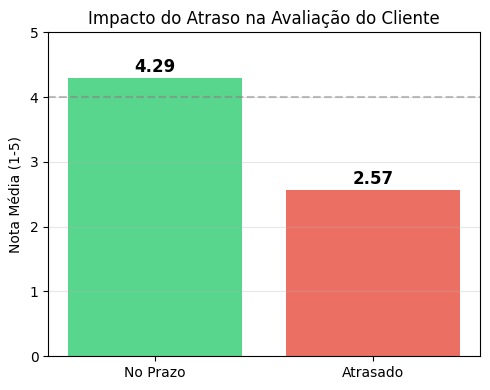

In [ ]:
df_comparacao = run_query("""
with frete as (
  select o.order_id ,
    o.order_purchase_timestamp as data_compra,
    o.order_delivered_customer_date as data_entrega,
    o.order_estimated_delivery_date as data_estimada,
    ((julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp))) as tempo_entrega_dias
  from orders o
  where tempo_entrega_dias is not null
  group by o.order_id
),
atrasada as (
  select f.order_id ,
    avg(f.tempo_entrega_dias ),
    avg(t.review_score ) as score_atrasado
  from frete f left join order_review t
  on f.order_id = t.order_id
  where f.data_entrega > f.data_estimada
),
no_prazo as (
  select f.order_id ,
    avg(f.tempo_entrega_dias ),
    avg(t.review_score ) as score_no_prazo
  from frete f left join order_review t
  on f.order_id = t.order_id
  where f.data_entrega <= f.data_estimada
)
SELECT b.score_no_prazo ,
  c.score_atrasado
from no_prazo b
join atrasada c
""")


categorias = ['No Prazo', 'Atrasado']
valores = [df_comparacao['score_no_prazo'].values[0],
           df_comparacao['score_atrasado'].values[0]]
cores = ['#2ECC71', '#E74C3C']

plt.figure(figsize=(5, 4))
bars = plt.bar(categorias, valores, color=cores, alpha=0.8)

for bar, valor in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{valor:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.ylabel('Nota Média (1-5)')
plt.title('Impacto do Atraso na Avaliação do Cliente')
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.3)

plt.axhline(y=4, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Análise de negócio:

Pedidos entregues no prazo têm nota média 4,29, enquanto os atrasados caem para 2,57. Uma diferença de 1,72 pontos que pode significar a diferença entre um cliente fiel e um cliente perdido.

Recomendação:
- Criar alerta para pedidos com risco de atraso (ex: já passaram de 80% do prazo)
- Aplicar medidas para melhora do calculo do prazo de entrega
- Para pedidos atrasados, oferecer automaticamente um cupom de 10% para próxima compra

**Análise concluída em:** Março/2026  
**Dados:** Olist Brazilian E-commerce (2016-2018)  
**Autor:** Kaique Leite | [LinkedIn](https://linkedin.com/in/leitekaique/)

## Conclusões Estratégicas

### Para o Time de Marketing:
1. **Foco em beleza_saude e relogios_presentes** - maiores receitas
2. **Produtos abaixo do preço médio com alto volume** (ex: ferramentas_jardim) - testar aumento controlado
3. **Sazonalidade** - preparar campanhas para meses de pico

### Para o Time de Operações:
1. **Gargalo logístico no Norte/Nordeste** - urgente revisar parcerias com transportadoras
2. **Impacto do atraso na satisfação** - nota cai de 4,29 para 2,57 quando atrasa
3. **Entregas >100 dias** - investigar causa (produtos importados? logística reversa?)

### Para o Time de Produto:
1. **Comunicar prazos realistas** - especialmente para regiões distantes
2. **Política de compensação para atrasos** - frete grátis na próxima compra
3. **Monitorar notas 1 e 2** - 14,6% das avaliações são críticas